In [76]:
import pandas as pd
import numpy as np
import pingouin as pg
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests


In [77]:
def run_posthoc_analysis(df_diff, label_name):
    """
    Führt deskriptive Statistiken, gepaarte t-Tests und Cohen's d 
    für jeden Block (pair) in einem gepivotteten DataFrame aus.
    """
    stats_list = []

    required_cols = ['pair', 'delay', 'no_delay', 'diff']
    if not all(col in df_diff.columns for col in required_cols):
        print(f"Fehler: DataFrame für {label_name} enthält nicht alle benötigten Spalten.")
        return None

    for p in sorted(df_diff['pair'].unique()):
        pair_data = df_diff[df_diff['pair'] == p].dropna()
        
        m_no_delay = pair_data['no_delay'].mean()
        sd_no_delay = pair_data['no_delay'].std()
        m_delay = pair_data['delay'].mean()
        sd_delay = pair_data['delay'].std()
        
        t_stat, p_unc = stats.ttest_rel(pair_data['delay'], pair_data['no_delay'])
        
        d = pair_data['diff'].mean() / pair_data['diff'].std()
        
        stats_list.append({
            "Block": p,
            "M_No_Delay": m_no_delay, "SD_No_Delay": sd_no_delay,
            "M_Delay": m_delay, "SD_Delay": sd_delay,
            "Diff": m_delay - m_no_delay,
            "t": t_stat,
            "p_unc": p_unc,
            "d": d
        })

    df_results = pd.DataFrame(stats_list)
    
    _, p_adj, _, _ = multipletests(df_results['p_unc'], method='fdr_bh')
    df_results['p_adj'] = p_adj

    print(f"\nPost-hoc Ergebnisse für {label_name}:")
    cols_to_print = ['Block', 'M_No_Delay', 'SD_No_Delay', 'M_Delay', 'SD_Delay', 'Diff', 't', 'p_adj', 'd']
    print(df_results[cols_to_print].round(3).to_string(index=False))
    
    return df_results

## Datenimport und Konsolidierung
Einlesen sämtlicher CSV-Dateien aus dem Verzeichnis `trialDataMainStudy` via `glob` und Zusammenführung in einen DataFrame `df` für die statistische Auswertung.

In [78]:
import glob

files = glob.glob("trialDataMainStudy/*.csv")

df = pd.concat(
    [pd.read_csv(f, sep=",") for f in files],
    ignore_index=True
)


In [79]:
df.head()


,id,gameType,round,trial,timestamp,time,mouseX,mouseY,position,effectDelay,startRT,endRT,RT,status,middleOrbExitCount;
0,1062,rld,0,1,14:07:42.371,639.4381,-2.563947,0.022230,left,0.0,638.7759,639.4381,0.662170,1,0;
1,1062,rld,0,2,14:07:44.188,641.2551,2.691165,0.048921,right,0.6,640.6176,641.2551,0.637451,1,0;
2,1062,rld,0,3,14:07:47.205,644.2722,-1.731190,0.028601,left,0.0,643.8556,644.2722,0.416626,0,1;
3,1062,rld,0,4,14:07:50.702,647.7686,-2.542882,0.100716,left,0.0,646.8018,647.7686,0.966736,1,2;
4,1062,rld,0,5,14:07:53.122,650.1898,2.527869,0.118092,right,0.6,649.5316,650.1898,0.658142,1,0;


In [80]:
df.columns

Index(['id', ' gameType', ' round', ' trial', ' timestamp', ' time', ' mouseX',
       ' mouseY', ' position', ' effectDelay', ' startRT', ' endRT', ' RT',
       ' status', ' middleOrbExitCount;'],
      dtype='str')

### Vorbereitung und Bereinigung der Daten
- Block-Bildung: Die 8 Runden wurden in 4 Blöcke (1-2, 3-4, 5-6, 7-8) zusammengefasst
- Nur erfolgreiche Versuche: Es wurden nur Trials gewertet, bei denen die Kugel korrekt getroffen wurde (status == 1)
- Erster Trial ausgeschlossen: Der jeweils erste Trial einer Runde wurde entfernt (trial != 1), da Probanden hier oft noch nicht bereit sind oder die Runde gerade erst startet
- Ausreißer-Korrektur: Reaktionszeiten über 4 Sekunden (4000 ms) wurden gelöscht, da dies eher auf Ablenkung als auf den experimentellen Effekt hindeutet

In [81]:
def round_to_block(r):
    if r in [1, 2]:
        return "1-2"
    elif r in [3, 4]:
        return "3-4"
    elif r in [5, 6]:
        return "5-6"
    elif r in [7, 8]:
        return "7-8"

df["Block"] = df[" round"].apply(round_to_block)

In [82]:
df = df[df[" round"] != 0]
print(df.head())
df["delay"] = df[" effectDelay"] == 0.6
df = df[df[" trial"] != 1]
df.loc[df[" RT"] >= 4, " status"] = 0


      id  gameType   round   trial      timestamp      time    mouseX  \
10  1062       rld       1       1   14:08:55.957  713.0242  2.393090   
11  1062       rld       1       2   14:08:58.445  715.5121 -2.528859   
12  1062       rld       1       3   14:09:00.349  717.4165 -2.482831   
13  1062       rld       1       4   14:09:02.233  719.3001 -2.518844   
14  1062       rld       1       5   14:09:04.021  721.0879  2.446890   

      mouseY  position   effectDelay   startRT     endRT        RT   status  \
10  0.108663     right           0.6  712.4286  713.0242  0.595581        1   
11 -0.004050      left           0.0  715.0416  715.5121  0.470520        1   
12  0.021978      left           0.0  716.8792  717.4165  0.537292        1   
13 -0.004075      left           0.0  718.8129  719.3001  0.487183        1   
14  0.108940     right           0.6  720.5799  721.0879  0.507996        1   

    middleOrbExitCount; Block  
10                   0;   1-2  
11                   0

In [83]:
def handle_outliers(group):
    clean_hits = group[(group[" status"] == 1) & (group[" RT"] < 4)][" RT"]
    m = clean_hits.mean()
    sd = clean_hits.std()
    
    outlier_condition = (group[" status"] == 1) & ((group[" RT"] > (m + 3*sd)) | (group[" RT"] < (m - 3*sd)))
    group.loc[outlier_condition, " status"] = 0
    return group

In [84]:
df

,id,gameType,round,trial,timestamp,time,mouseX,mouseY,position,effectDelay,startRT,endRT,RT,status,middleOrbExitCount;,Block,delay
11,1062,rld,1,2,14:08:58.445,715.5121,-2.528859,-0.004050,left,0.0,715.0416,715.5121,0.470520,1,0;,1-2,False
12,1062,rld,1,3,14:09:00.349,717.4165,-2.482831,0.021978,left,0.0,716.8792,717.4165,0.537292,1,0;,1-2,False
13,1062,rld,1,4,14:09:02.233,719.3001,-2.518844,-0.004075,left,0.0,718.8129,719.3001,0.487183,1,0;,1-2,False
14,1062,rld,1,5,14:09:04.021,721.0879,2.446890,0.108940,right,0.6,720.5799,721.0879,0.507996,1,0;,1-2,True
15,1062,rld,1,6,14:09:08.892,725.9595,-3.287091,0.006957,left,0.0,725.2138,725.9595,0.745667,0,1;,1-2,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21065,9993,lld,8,56,17:19:32.329,1887.8530,2.772861,-0.047360,right,0.0,1887.2280,1887.8530,0.624756,1,1;,7-8,False
21066,9993,lld,8,57,17:19:34.933,1890.4580,2.855240,-0.047238,right,0.0,1889.7620,1890.4580,0.695801,1,1;,7-8,False
21067,9993,lld,8,58,17:19:36.600,1892.1240,2.663580,-0.082634,right,0.0,1891.4370,1892.1240,0.687256,1,0;,7-8,False
21068,9993,lld,8,59,17:19:37.992,1893.5160,2.836896,-0.108827,right,0.0,1893.0080,1893.5160,0.508057,1,0;,7-8,False


In [85]:
id_backup = df["id"]

In [86]:
df = df.groupby("id", group_keys=False).apply(handle_outliers)

In [87]:
df["id"] = id_backup

In [88]:
len(df)
df

,gameType,round,trial,timestamp,time,mouseX,mouseY,position,effectDelay,startRT,endRT,RT,status,middleOrbExitCount;,Block,delay,id
11,rld,1,2,14:08:58.445,715.5121,-2.528859,-0.004050,left,0.0,715.0416,715.5121,0.470520,1,0;,1-2,False,1062
12,rld,1,3,14:09:00.349,717.4165,-2.482831,0.021978,left,0.0,716.8792,717.4165,0.537292,1,0;,1-2,False,1062
13,rld,1,4,14:09:02.233,719.3001,-2.518844,-0.004075,left,0.0,718.8129,719.3001,0.487183,1,0;,1-2,False,1062
14,rld,1,5,14:09:04.021,721.0879,2.446890,0.108940,right,0.6,720.5799,721.0879,0.507996,1,0;,1-2,True,1062
15,rld,1,6,14:09:08.892,725.9595,-3.287091,0.006957,left,0.0,725.2138,725.9595,0.745667,0,1;,1-2,False,1062
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21065,lld,8,56,17:19:32.329,1887.8530,2.772861,-0.047360,right,0.0,1887.2280,1887.8530,0.624756,1,1;,7-8,False,9993
21066,lld,8,57,17:19:34.933,1890.4580,2.855240,-0.047238,right,0.0,1889.7620,1890.4580,0.695801,1,1;,7-8,False,9993
21067,lld,8,58,17:19:36.600,1892.1240,2.663580,-0.082634,right,0.0,1891.4370,1892.1240,0.687256,1,0;,7-8,False,9993
21068,lld,8,59,17:19:37.992,1893.5160,2.836896,-0.108827,right,0.0,1893.0080,1893.5160,0.508057,1,0;,7-8,False,9993


In [89]:
df_er = df.groupby(["id", "Block", "delay"])[" status"].apply(
    lambda x: (x == 0).mean() * 100
).reset_index(name="ER")

print(df_er.groupby(["Block", "delay"])["ER"].mean())

Block  delay
1-2    False     8.687086
       True      8.020220
3-4    False     9.463118
       True      6.505897
5-6    False    11.441222
       True      8.167285
7-8    False    10.600990
       True      7.621433
Name: ER, dtype: float64


In [90]:
df_er.head()

,id,Block,delay,ER
0,1062,1-2,False,10.000000
1,1062,1-2,True,10.344828
2,1062,3-4,False,23.728814
3,1062,3-4,True,11.864407
4,1062,5-6,False,6.666667


In [91]:
df_er_diff = df_er.pivot(index=["id", "Block"], columns="delay", values="ER").reset_index()
df_er_diff["ER_diff"] = df_er_diff[True] - df_er_diff[False]

print(df_er_diff.head())

delay    id Block      False       True    ER_diff
0      1062   1-2  10.000000  10.344828   0.344828
1      1062   3-4  23.728814  11.864407 -11.864407
2      1062   5-6   6.666667  10.344828   3.678161
3      1062   7-8  23.728814  23.728814   0.000000
4      1099   1-2   0.000000   0.000000   0.000000


In [ ]:
desc_delay = df_er.groupby("delay")["ER"].agg(["mean", "std"])
print("--- Werte für den Haupteffekt Delay ER ---")
print(desc_delay)

df_pivot = df_er.pivot(index=["id", "Block"], columns="delay", values="ER").reset_index()

cols = sorted([c for c in df_pivot.columns if c not in ["id", "Block"]])
no_delay_col = cols[0] 
delay_col = cols[1]

results = []

for block in sorted(df_pivot["Block"].unique()):
    block_data = df_pivot[df_pivot["Block"] == block].dropna(subset=[no_delay_col, delay_col])
    
    nd = block_data[no_delay_col]
    d_val = block_data[delay_col]
    
    m_nd, sd_nd = nd.mean(), nd.std()
    m_d, sd_d = d_val.mean(), d_val.std()
    
    diff = m_d - m_nd
    t_stat, p_val = stats.ttest_rel(d_val, nd)
    df_val = len(block_data) - 1
    
    diff_scores = d_val - nd
    cohen_d = diff_scores.mean() / diff_scores.std() if diff_scores.std() != 0 else 0
    
    results.append({
        "Block": block,
        "M No Delay": m_nd, "SD No Delay": sd_nd,
        "M Delay": m_d, "SD Delay": sd_d,
        "Diff": diff, "t": t_stat, "df": df_val, "p_unc": p_val, "d": cohen_d
    })

df_table = pd.DataFrame(results)

_, p_adj, _, _ = multipletests(df_table['p_unc'], method='fdr_bh')
df_table['p_adj'] = p_adj

print("Error Rate (ER, in %)")
print(df_table.round(3).to_markdown(index=False))

--- Werte für den Haupteffekt Delay ER ---
            mean        std
delay                      
False  10.048104  10.949014
True    7.578709   8.068385
Error Rate (ER, in %)
| Block   |   M No Delay |   SD No Delay |   M Delay |   SD Delay |   Diff |      t |   df |   p_unc |      d |   p_adj |
|:--------|-------------:|--------------:|----------:|-----------:|-------:|-------:|-----:|--------:|-------:|--------:|
| 1-2     |        8.687 |         8.844 |     8.02  |      8.08  | -0.667 | -1.077 |   42 |   0.288 | -0.164 |   0.288 |
| 3-4     |        9.463 |        10.719 |     6.506 |      7.085 | -2.957 | -2.899 |   42 |   0.006 | -0.442 |   0.021 |
| 5-6     |       11.441 |        12.256 |     8.167 |      8.109 | -3.274 | -2.674 |   42 |   0.011 | -0.408 |   0.021 |
| 7-8     |       10.601 |        11.842 |     7.621 |      9.059 | -2.98  | -2.521 |   42 |   0.016 | -0.384 |   0.021 |


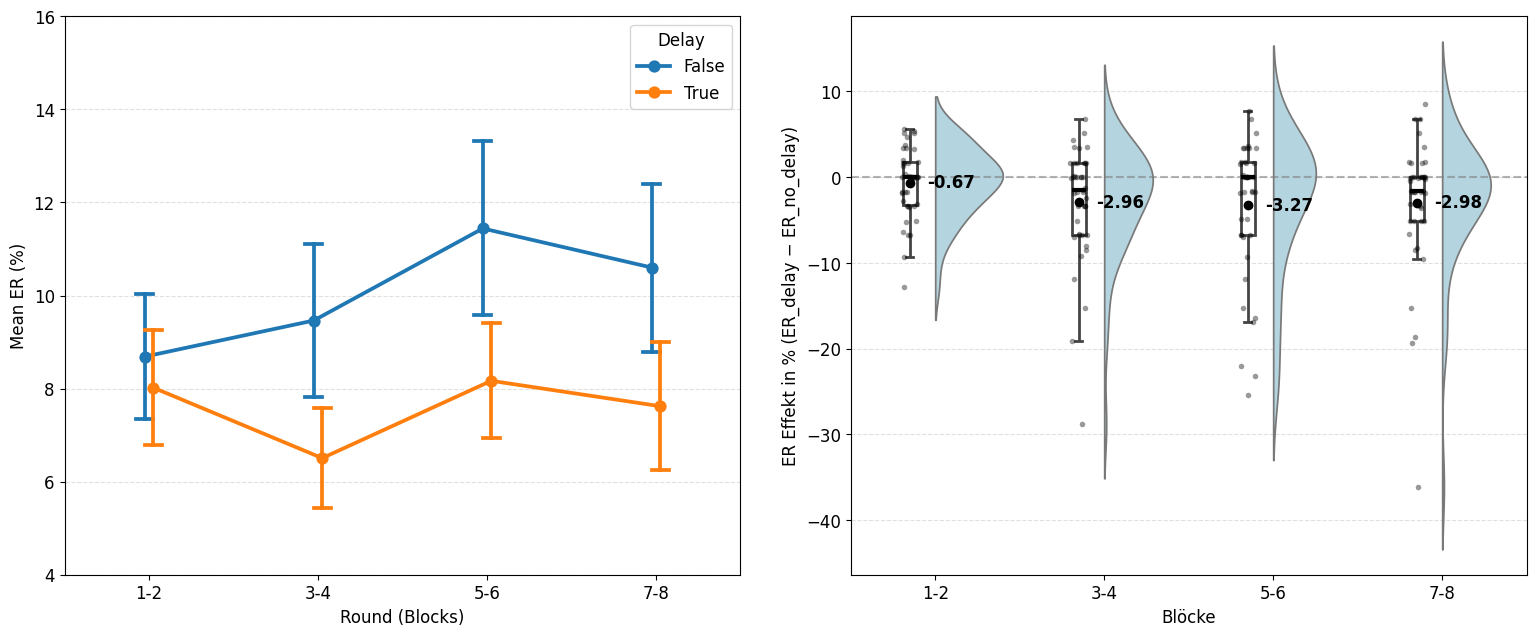

In [93]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import PolyCollection
from matplotlib.patches import PathPatch

base_size = 12  
fig, ax = plt.subplots(1, 2, figsize=(16, 7))

sns.pointplot(
    data=df_er, 
    x="Block", 
    y="ER", 
    hue="delay", 
    errorbar="se", 
    dodge=True,
    markers=["o", "o"],
    capsize=.1,
    ax=ax[0]
)

ax[0].set_axisbelow(True)
ax[0].grid(axis='y', linestyle='--', alpha=0.7, color='lightgrey')
ax[0].set_ylabel("Mean ER (%)", fontsize=base_size)
ax[0].set_xlabel("Round (Blocks)", fontsize=base_size)
ax[0].set_ylim(4, 16)
ax[0].tick_params(labelsize=base_size)
ax[0].legend(title="Delay", fontsize=base_size, title_fontsize=base_size)


sns.violinplot(
    data=df_er_diff, x="Block", y="ER_diff", 
    inner=None, color="lightblue", alpha=1, ax=ax[1]
)

for art in ax[1].findobj(PolyCollection):
    for path in art.get_paths():
        center = np.mean(path.vertices[:, 0])
        path.vertices[:, 0] = np.maximum(path.vertices[:, 0], center)

sns.boxplot(
    data=df_er_diff, x="Block", y="ER_diff", 
    width=0.08, color="white", linewidth=2, showfliers=False, 
    showmeans=True,
    boxprops={'edgecolor': '#444444', 'facecolor': 'white'},
    whiskerprops={'color': '#444444'},
    capprops={'color': '#444444'},
    meanprops={"marker":"o", "markerfacecolor":"black", "markeredgecolor":"black", "markersize":"6"},
    medianprops={'color': 'black', 'linewidth': 3},
    ax=ax[1], zorder=10
)

sns.stripplot(
    data=df_er_diff, x="Block", y="ER_diff", 
    color="black", alpha=0.4, size=4, jitter=0.05, ax=ax[1], zorder=20
)


offset = -0.15 
for artist in ax[1].collections:
    if not isinstance(artist, PolyCollection):
        offsets = artist.get_offsets()
        offsets[:, 0] = offsets[:, 0] + offset
        artist.set_offsets(offsets)

for patch in ax[1].patches:
    if isinstance(patch, PathPatch):
        path = patch.get_path()
        for i in range(len(path.vertices)):
            path.vertices[i, 0] += offset

for line in ax[1].lines:
    if line.get_linestyle() != "--":
        line.set_xdata(line.get_xdata() + offset)

means = df_er_diff.groupby("Block")["ER_diff"].mean()
for i, block in enumerate(df_er_diff["Block"].unique()):
    val = means[block]
    ax[1].text(i + offset + 0.1, val, f"{val:.2f}", 
               verticalalignment='center', fontsize=base_size, fontweight='bold', color='black')

ax[1].set_axisbelow(True)
ax[1].grid(axis='y', linestyle='--', alpha=0.7, color='lightgrey')
ax[1].axhline(0, linestyle="--", color="grey", alpha=0.6, linewidth=1.5)
ax[1].set_ylabel("ER Effekt in % (ER_delay − ER_no_delay)", fontsize=base_size)
ax[1].set_xlabel("Blöcke", fontsize=base_size)
ax[1].tick_params(labelsize=base_size)

plt.subplots_adjust(wspace=0.3) 
plt.tight_layout(pad=3.0) 

plt.show()

In [94]:
aov_er = pg.rm_anova(
    dv="ER", 
    within=["delay", "Block"], 
    subject="id", 
    data=df_er
)

print("ANOVA Ergebnisse für Error Rate:")
print(aov_er)

ANOVA Ergebnisse für Error Rate:
          Source          SS  ddof1  ddof2          MS          F     p_unc  \
0          delay  524.420605      1     42  524.420605  10.967433  0.001913   
1          Block  169.326433      3    126   56.442144   2.033258  0.112578   
2  delay * Block   94.484731      3    126   31.494910   2.096099  0.104053   

   p_GG_corr       ng2       eps  
0   0.001913  0.016444  1.000000  
1   0.125464  0.005369  0.820187  
2   0.114813  0.003003  0.850706  


In [95]:
df = df[df[" status"] == 1]
df = df[df[" RT"] < 4]


Erstellung einer Spalte `delay`, die kennzeichnet, ob in einem Trial die spezifische Verzögerung von 0,6 Sekunden (`effectDelay`) vorlag.

In [96]:
df["delay"] = df[" effectDelay"] == 0.6


In [97]:
df_delay = df[df["delay"] == True]
df_no_delay = df[df["delay"] == False]



## Aggregation der Reaktionszeiten
Berechnung der mittleren Reaktionszeit (`meanRT`) pro Proband (`id`), Versuchsblock (`Block`) und Bedingung (`delay`).

In [98]:
df_agg = (
    df
    .groupby(["id", "Block", "delay"], as_index=False)
    .agg(meanRT=(" RT", "mean"))
)


In [99]:
df_agg.head()

,id,Block,delay,meanRT
0,1062,1-2,False,0.517867
1,1062,1-2,True,0.543090
2,1062,3-4,False,0.494444
3,1062,3-4,True,0.539969
4,1062,5-6,False,0.587396


In [100]:
df_agg.head()
df_agg.groupby(["Block", "delay"]).size()


Block  delay
1-2    False    43
       True     43
3-4    False    43
       True     43
5-6    False    43
       True     43
7-8    False    43
       True     43
dtype: int64

## Berechnung der Block-Mittelwerte
Ermittlung der durchschnittlichen Reaktionszeiten pro Versuchsblock und Bedingung (`delay`).

In [101]:
df_agg["meanRT"] = df_agg["meanRT"]*1000


In [102]:
mean_by_block_delay = df_agg.groupby(["Block", "delay"])["meanRT"].mean().reset_index()

print(mean_by_block_delay)

  Block  delay      meanRT
0   1-2  False  630.441199
1   1-2   True  639.482921
2   3-4  False  572.573138
3   3-4   True  588.440975
4   5-6  False  540.557408
5   5-6   True  565.164520
6   7-8  False  527.952909
7   7-8   True  559.195043


In [103]:
df_pivot = df_agg.pivot(index=['id', 'Block'], columns='delay', values='meanRT').reset_index()
df_pivot.columns = ['id', 'Block', 'No_Delay', 'Delay']

stats_list = []

for block in sorted(df_pivot['Block'].unique()):
    block_data = df_pivot[df_pivot['Block'] == block].dropna()
    
    m_nd, sd_nd = block_data['No_Delay'].mean(), block_data['No_Delay'].std()
    m_d, sd_d = block_data['Delay'].mean(), block_data['Delay'].std()
    
    t_stat, p_unc = stats.ttest_rel(block_data['Delay'], block_data['No_Delay'])
    
    diff_scores = block_data['Delay'] - block_data['No_Delay']
    d = diff_scores.mean() / diff_scores.std()
    
    stats_list.append({
        "Block": block,
        "M_No_Delay": m_nd, "SD_No_Delay": sd_nd,
        "M_Delay": m_d, "SD_Delay": sd_d,
        "Diff": m_d - m_nd,
        "t": t_stat,
        "p_unc": p_unc,
        "d": d
    })

df_results = pd.DataFrame(stats_list)
_, p_adj, _, _ = multipletests(df_results['p_unc'], method='fdr_bh')
df_results['p'] = p_adj

# Ausgabe der Tabelle
print(df_results[['Block', 'M_No_Delay', 'SD_No_Delay', 'M_Delay', 'SD_Delay', 'Diff', 't', 'p', 'd']].round(2))

  Block  M_No_Delay  SD_No_Delay  M_Delay  SD_Delay   Diff     t     p     d
0   1-2      630.44       116.57   639.48    114.02   9.04  1.71  0.09  0.26
1   3-4      572.57       107.28   588.44    106.16  15.87  3.46  0.00  0.53
2   5-6      540.56       107.99   565.16    111.38  24.61  5.07  0.00  0.77
3   7-8      527.95       117.78   559.20    116.91  31.24  5.93  0.00  0.90


## Verlaufsgrafik der Reaktionszeiten
Erstellung eines Pointplots, um die Veränderung der mittleren Reaktionszeit über die Blöcke hinweg darzustellen.

## Differenz der Reaktionszeiten berechnen
Die Daten werden so umgeformt (Pivot), dass die Werte mit und ohne Delay direkt nebeneinander in einer Zeile stehen. Dann wird die Differenz (`RT_diff`) zwischen beiden Bedingungen berechnet, um den Effekt der Verzögerung pro Proband und Block zu isolieren.

In [104]:
df_diff = (
    df_agg
    .pivot(index=["id", "Block"], columns="delay", values="meanRT")
    .reset_index()
)

df_diff["RT_diff"] = df_diff[True] - df_diff[False]


## Visualisierung des Delay-Effekts
Hier wird der Unterschied zwischen den Bedingungen (Delay minus kein Delay) über die Blöcke hinweg dargestellt.

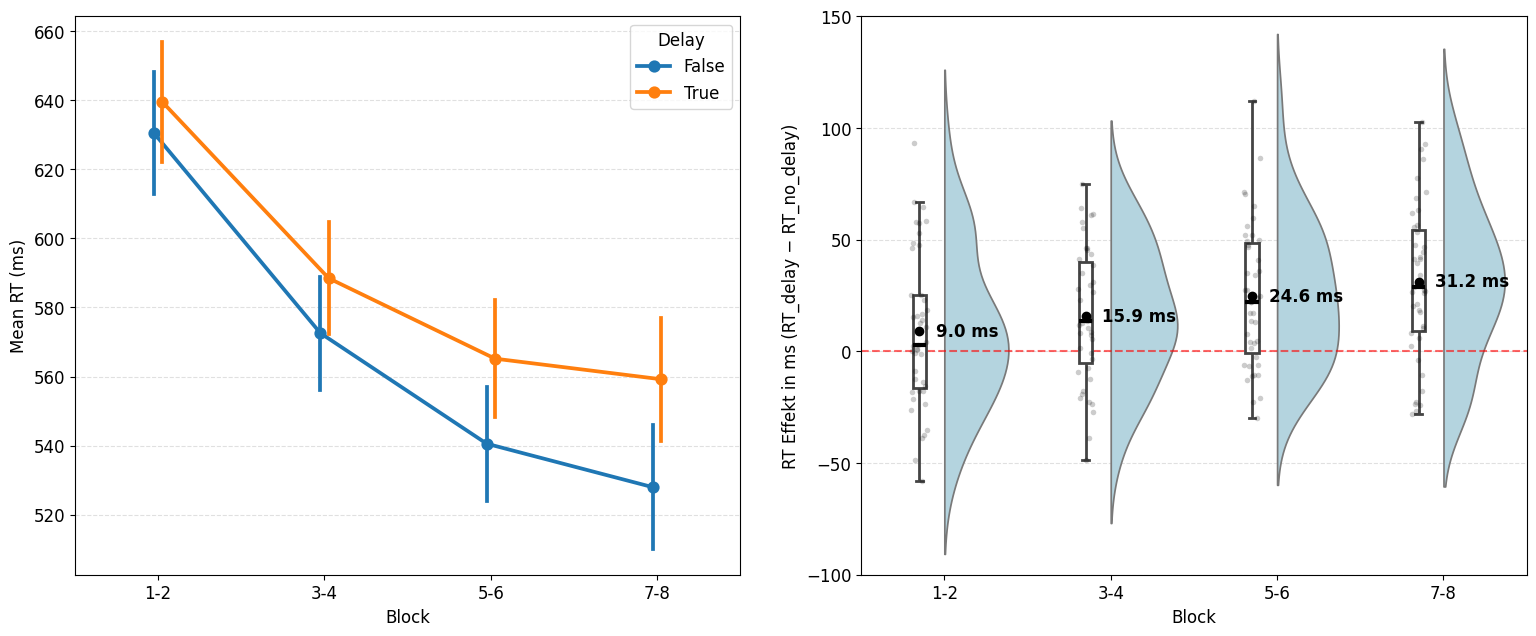

In [105]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import PolyCollection
from matplotlib.patches import PathPatch

base_size = 12 
fig, ax = plt.subplots(1, 2, figsize=(16, 7))

sns.pointplot(
    data=df_agg,
    x="Block",
    y="meanRT",
    hue="delay",
    errorbar="se",
    dodge=True,
    ax=ax[0]
)

ax[0].set_axisbelow(True)
ax[0].grid(axis='y', linestyle='--', alpha=0.7, color='lightgrey')
ax[0].set_ylabel("Mean RT (ms)", fontsize=base_size) 
ax[0].set_xlabel("Block", fontsize=base_size)
ax[0].tick_params(labelsize=base_size)
ax[0].legend(title="Delay", fontsize=base_size, title_fontsize=base_size)


plot_df = df_diff.copy()
target_col = "RT_diff"

sns.violinplot(
    data=plot_df, x="Block", y=target_col, 
    inner=None, color="lightblue", alpha=1, ax=ax[1]
)

for art in ax[1].findobj(PolyCollection):
    for path in art.get_paths():
        center = np.mean(path.vertices[:, 0])
        path.vertices[:, 0] = np.maximum(path.vertices[:, 0], center)

sns.boxplot(
    data=plot_df, x="Block", y=target_col, 
    width=0.08, color="white", linewidth=2, showfliers=False, 
    showmeans=True,
    boxprops={'edgecolor': '#444444', 'facecolor': 'white'},
    whiskerprops={'color': '#444444'},
    capprops={'color': '#444444'},
    meanprops={"marker":"o", "markerfacecolor":"black", "markeredgecolor":"black", "markersize":"6"},
    medianprops={'color': 'black', 'linewidth': 3},
    ax=ax[1], zorder=10
)

sns.stripplot(
    data=plot_df, x="Block", y=target_col, 
    color="black", alpha=0.2, size=4, jitter=0.05, ax=ax[1], zorder=20
)

offset = -0.15 
for artist in ax[1].collections:
    if not isinstance(artist, PolyCollection):
        offsets = artist.get_offsets()
        offsets[:, 0] = offsets[:, 0] + offset
        artist.set_offsets(offsets)

for patch in ax[1].patches:
    if isinstance(patch, PathPatch):
        path = patch.get_path()
        for i in range(len(path.vertices)):
            path.vertices[i, 0] += offset

for line in ax[1].lines:
    if line.get_linestyle() != "--":
        line.set_xdata(line.get_xdata() + offset)

means = plot_df.groupby("Block")[target_col].mean()
for i, block in enumerate(sorted(plot_df["Block"].unique())):
    val = means[block]
    ax[1].text(i + offset + 0.1, val, f"{val:.1f} ms", 
               verticalalignment='center', fontsize=base_size, fontweight='bold', color='black')

ax[1].axhline(0, linestyle="--", color="red", alpha=0.6, linewidth=1.5)
ax[1].set_axisbelow(True)
ax[1].grid(axis='y', linestyle='--', alpha=0.7, color='lightgrey')
ax[1].set_ylim(-100, 150)
ax[1].set_ylabel("RT Effekt in ms (RT_delay − RT_no_delay)", fontsize=base_size)
ax[1].set_xlabel("Block", fontsize=base_size)
ax[1].tick_params(labelsize=base_size)

plt.subplots_adjust(wspace=0.3) 

plt.tight_layout(pad=3.0) 

plt.show()

## Datentypen anpassen
Hier werden die Spalten `Block` und `delay` in Kategorien umgewandelt. Das ist wichtig, damit sie bei der späteren statistischen Analyse (z. B. ANOVA) korrekt als Gruppen behandelt werden.

In [106]:
df_agg["Block"] = df_agg["Block"].astype("category")
df_agg["delay"] = df_agg["delay"].astype("category")


## Messwiederholungs-ANOVA (rmANOVA)
Statistische Überprüfung der Haupteffekte und Interaktionen:
- **Haupteffekt Delay:** Hat die Verzögerung einen generellen Einfluss auf die Reaktionszeit?
- **Haupteffekt Block:** Verändern sich die Zeiten über die vier Blöcke (z. B. Lerneffekt)?
- **Interaktion (Block * Delay):** Verändert sich der Effekt der Verzögerung im Laufe des Experiments?

In [107]:
import pingouin as pg

aov = pg.rm_anova(
    dv="meanRT",
    within=["Block", "delay"],
    subject="id",
    data=df_agg,
    detailed=True
)

print(aov)


          Source             SS  ddof1  ddof2             MS          F  \
0          Block  435855.015939      3    126  145285.005313  41.288134   
1          delay   35055.666247      1     42   35055.666247  22.895712   
2  Block * delay    6119.453293      3    126    2039.817764   9.838263   

          p_unc     p_GG_corr       ng2       eps  
0  1.184943e-18  7.044135e-15  0.093193  0.768505  
1  2.133415e-05  2.133415e-05  0.008198  1.000000  
2  7.069438e-06  3.329854e-05  0.001441  0.828434  


## Ergebnisse der Varianzanalyse (ANOVA)

Alle untersuchten Effekte sind statistisch signifikant:

* **Haupteffekt Block:** Es gibt einen deutlichen Unterschied zwischen den Blöcken ($F(3, 126) = 40.08, p < .001$). Die Reaktionszeiten verändern sich also signifikant über den Zeitverlauf.
* **Haupteffekt Delay:** Die Verzögerung hat einen klaren Einfluss auf die Geschwindigkeit ($F(1, 42) = 22.35, p < .001$).
* **Interaktion (Block * Delay):** Der Effekt der Verzögerung ist nicht in allen Blöcken gleich, sondern verändert sich im Verlauf des Experiments ($F(3, 126) = 8.96, p < .001$).

**Kurzgefasst:** Sowohl die Übung (Blöcke) als auch die Verzögerung beeinflussen die Performance, wobei die Verzögerung je nach Fortschritt des Experiments unterschiedlich stark wirkt.

### Post hoc Paired T-Test

In [108]:
posthoc = pg.pairwise_tests(
    dv="meanRT",
    within="delay",
    subject="id",
    data=df_agg,
    padjust="bonf",
    parametric=True
)

print(posthoc)


  Contrast      A     B  Paired  Parametric         T   dof alternative  \
0    delay  False  True    True        True -4.784946  42.0   two-sided   

      p_unc     BF10    hedges  
0  0.000021  983.878 -0.188857  


In [109]:
posthoc_block = pg.pairwise_tests(
    dv="meanRT",
    within="delay",
    subject="id",
    between=None,
    data=df_agg,
    padjust="bonf",
    parametric=True,
    within_first=True
)

print(posthoc_block)


  Contrast      A     B  Paired  Parametric         T   dof alternative  \
0    delay  False  True    True        True -4.784946  42.0   two-sided   

      p_unc     BF10    hedges  
0  0.000021  983.878 -0.188857  


In [110]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import PolyCollection
from matplotlib.patches import PathPatch

def plot_results(stat_df, diff_df, y_col, ylabel_left, ylabel_right, pair_order=None, base_size=12, decimals = 1):
    """
    Erstellt einen kombinierten Plot: 
    Links Interaction-Plot (Pointplot), rechts Raincloud-Plot (Differenz).
    """
    fig, ax = plt.subplots(1, 2, figsize=(18, 7))
    
    sns.pointplot(
        data=stat_df,
        x="pair",
        y=y_col,
        hue="condition",
        errorbar="se",
        order=pair_order,
        dodge=True,
        ax=ax[0]
    )

    ax[0].set_ylabel(ylabel_left, fontsize=base_size)
    ax[0].set_xlabel("Block", fontsize=base_size)
    ax[0].grid(axis='y', linestyle='--', alpha=0.7)
    ax[0].legend(title="Condition")

    target_col = "diff"
    x_col = "pair"
    
    sns.violinplot(
        data=diff_df, x=x_col, y=target_col, 
        inner=None, color="lightblue", alpha=1, ax=ax[1], order=pair_order
    )

    for art in ax[1].findobj(PolyCollection):
        for path in art.get_paths():
            center = np.mean(path.vertices[:, 0])
            path.vertices[:, 0] = np.maximum(path.vertices[:, 0], center)

    sns.boxplot(
        data=diff_df, x=x_col, y=target_col, 
        width=0.06, color="white", linewidth=2, showfliers=False, 
        showmeans=True,
        boxprops={'edgecolor': '#444444', 'facecolor': 'white'},
        whiskerprops={'color': '#444444'},
        capprops={'color': '#444444'},
        meanprops={"marker":"o", "markerfacecolor":"black", "markeredgecolor":"black", "markersize":"6"},
        medianprops={'color': 'black', 'linewidth': 3},
        ax=ax[1], zorder=10, order=pair_order
    )

    sns.stripplot(
        data=diff_df, x=x_col, y=target_col, 
        color="black", alpha=0.2, size=4, jitter=0.05, ax=ax[1], zorder=20, order=pair_order
    )

    offset = -0.15 
    for artist in ax[1].collections:
        if not isinstance(artist, PolyCollection):
            offsets = artist.get_offsets()
            offsets[:, 0] = offsets[:, 0] + offset
            artist.set_offsets(offsets)

    for patch in ax[1].patches:
        if isinstance(patch, PathPatch):
            path = patch.get_path()
            for i in range(len(path.vertices)):
                path.vertices[i, 0] += offset

    for line in ax[1].lines:
        if line.get_linestyle() != "--":
            line.set_xdata(line.get_xdata() + offset)

    means = diff_df.groupby(x_col)[target_col].mean()
    current_order = pair_order if pair_order is not None else sorted(diff_df[x_col].unique())
    
    for i, block in enumerate(current_order):
        if block in means:
            val = means[block]
            ax[1].text(i + offset + 0.1, val, f"{val:.{decimals}f}", 
                       verticalalignment='center', fontsize=10, fontweight='bold', color='black')

    ax[1].axhline(0, linestyle="--", color="red", alpha=0.6, linewidth=1.5)
    ax[1].set_ylabel(ylabel_right, fontsize=base_size)
    ax[1].set_xlabel("Block", fontsize=base_size)
    ax[1].grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout(pad=3.0)
    return fig, ax

## Laden der aggregierten Daten
Import der zuvor erstellten Datei `agg_df.csv`, die die zusammengefassten Kennwerte der Studie enthält.

In [111]:
stat_df = pd.read_csv("agg_df.csv", encoding="utf-8")

print(stat_df.head())

     id condition pair  time_to_ballistic_start  avg_ballistic_speed  \
0  1062     delay  1_2               220.250000            16.381319   
1  1062     delay  3_4               205.788462            16.443773   
2  1062     delay  5_6               207.173077            16.820034   
3  1062     delay  7_8               209.377778            18.597047   
4  1062  no_delay  1_2               216.148148            15.369429   

   overshoots  undershoots  max_ballistic_speed  verification_duration  \
0    0.057692     0.230769            33.610066              76.538462   
1    0.019231     0.211538            31.556219              94.807692   
2    0.115385     0.461538            34.019841             103.269231   
3    0.022222     0.133333            34.026858              58.288889   
4    0.055556     0.092593            30.763832              85.740741   

   correction_duration  ballistic_duration       auc  
0            65.211538          171.057692  0.110950  
1           

## Vergleich der ballistichen Geschwindigkeit
Visualisierung der durchschnittlichen ballistichen Geschwindigkeit (`avg_ballistic_speed`) über die verschiedenen Trial-Paare hinweg. Der Vergleich erfolgt getrennt nach Versuchsbedingung (`condition`), um zu sehen, wie sich das Tempo im Verlauf der Blöcke verändert.

In [112]:
df_diff_avg_ballistic_speed = stat_df.pivot_table(
    index=['id', 'pair'], 
    columns='condition', 
    values='avg_ballistic_speed'
).reset_index()
df_diff_avg_ballistic_speed['diff'] = df_diff_avg_ballistic_speed['delay'] - df_diff_avg_ballistic_speed['no_delay']

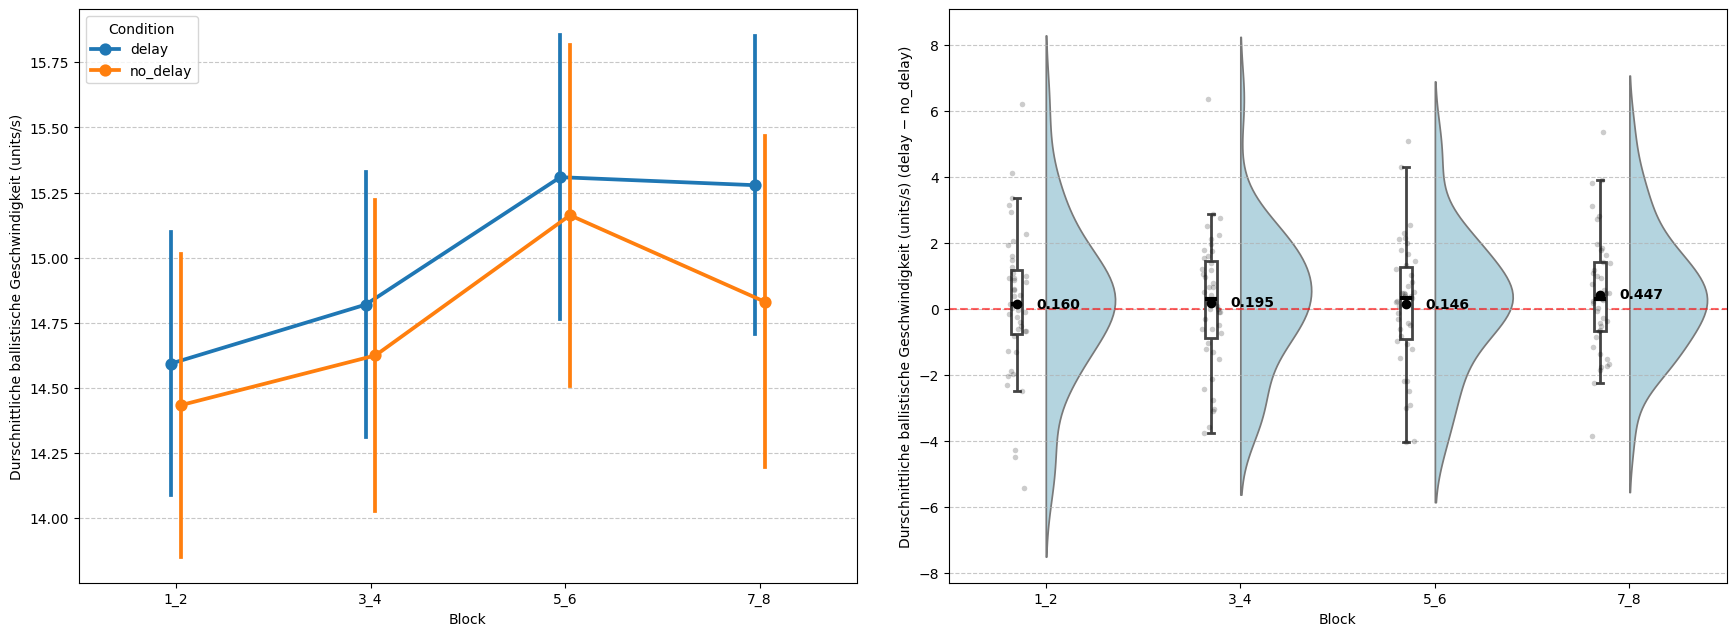

In [113]:
fig, ax = plot_results(
    stat_df=stat_df, 
    diff_df=df_diff_avg_ballistic_speed, 
    y_col="avg_ballistic_speed", 
    ylabel_left="Durschnittliche ballistische Geschwindigkeit (units/s)", 
    ylabel_right="Durschnittliche ballistische Geschwindigkeit (units/s) (delay − no_delay)",
    pair_order=None,
    base_size=10,
    decimals=3
)

## ANOVA: Ballistische Geschwindigkeit
Statistische Überprüfung, ob die Bedingung (Condition) und der zeitliche Verlauf (Pair) die ballistische Geschwindigkeit beeinflussen. Außerdem wird getestet, ob es eine Interaktion gibt – also ob die Bedingung je nach Trial-Paar unterschiedlich wirkt.

In [114]:
aov = pg.rm_anova(
    dv="avg_ballistic_speed",
    within=["condition", "pair"],
    subject="id",
    data=stat_df,
    detailed=True
)

print(aov)

             Source         SS  ddof1  ddof2        MS         F     p_unc  \
0         condition   4.828591      1     42  4.828591  0.771778  0.384666   
1              pair  27.174721      3    126  9.058240  3.642177  0.014628   
2  condition * pair   1.291495      3    126  0.430498  0.765046  0.515696   

   p_GG_corr       ng2       eps  
0   0.384666  0.001003  1.000000  
1   0.028111  0.005617  0.702288  
2   0.499295  0.000268  0.868521  


## Verlauf der maximalen ballistischen Geschwindigkeit
Visualisierung der Spitzen-Geschwindigkeit (`max_ballistic_speed`) über die verschiedenen Trial-Paare.

In [115]:
df_diff_max_ballistic_speed = stat_df.pivot_table(
    index=['id', 'pair'], 
    columns='condition', 
    values='max_ballistic_speed'
).reset_index()
df_diff_max_ballistic_speed['diff'] = df_diff_max_ballistic_speed['delay'] - df_diff_max_ballistic_speed['no_delay']

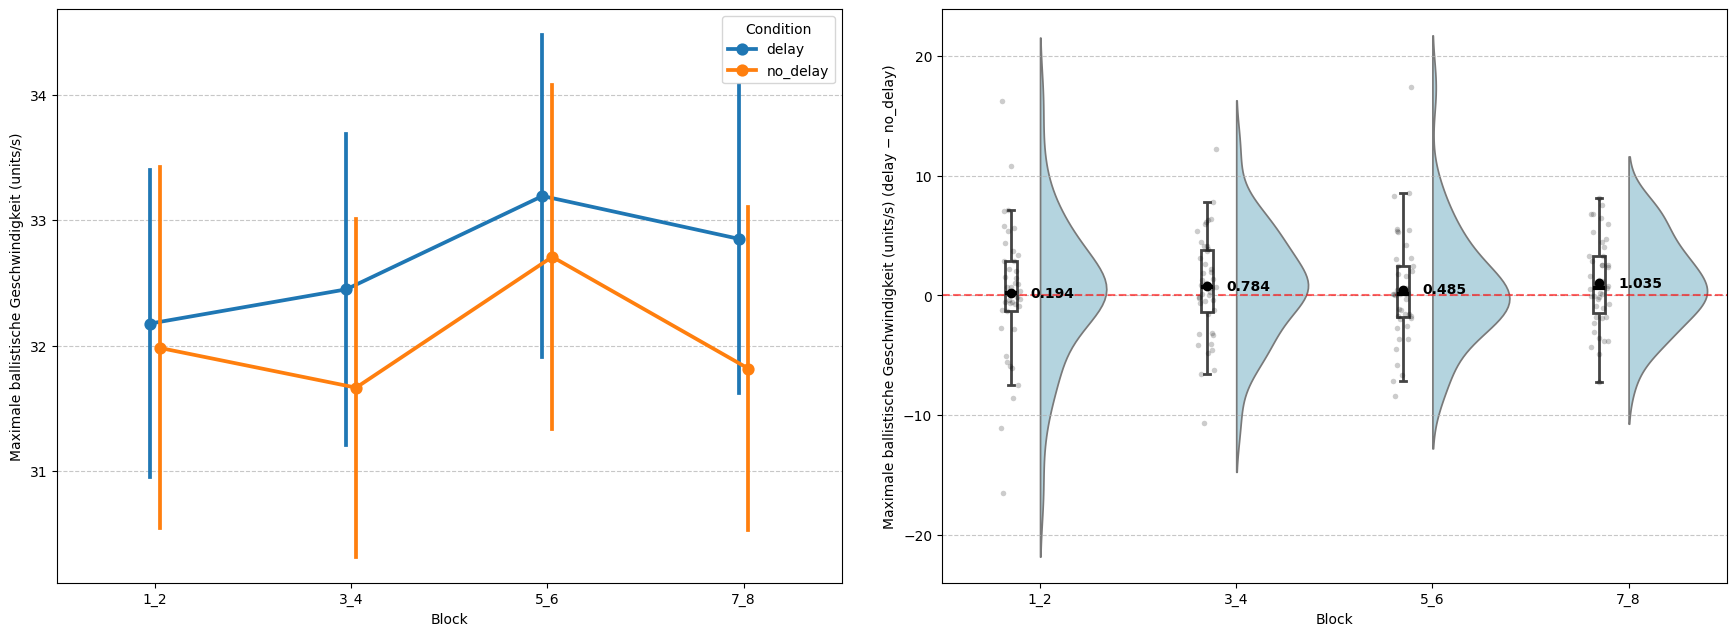

In [116]:
fig, ax = plot_results(
    stat_df=stat_df, 
    diff_df=df_diff_max_ballistic_speed, 
    y_col="max_ballistic_speed", 
    ylabel_left="Maximale ballistische Geschwindigkeit (units/s)", 
    ylabel_right="Maximale ballistische Geschwindigkeit (units/s) (delay − no_delay)",
    pair_order=None,
    base_size=10,
    decimals=3
)

In [117]:
aov = pg.rm_anova(
    dv="max_ballistic_speed",
    within=["condition", "pair"],
    subject="id",
    data=stat_df,
    detailed=True
)

print(aov)

             Source         SS  ddof1  ddof2         MS         F     p_unc  \
0         condition  33.550956      1     42  33.550956  1.016077  0.319224   
1              pair  44.737306      3    126  14.912435  1.664077  0.178115   
2  condition * pair   8.567398      3    126   2.855799  0.901599  0.442486   

   p_GG_corr       ng2       eps  
0   0.319224  0.001364  1.000000  
1   0.192765  0.001818  0.723248  
2   0.416685  0.000349  0.724239  


## Analyse des Startzeitpunkts der ballistischen Phase
Dieser Plot zeigt die Dauer bis zum Beginn der ballistischen Phase (`time_to_ballistic_start`). Damit untersuchen wir, ob das Delay einen Einfluss darauf hat, wie schnell die Probanden die eigentliche Zielbewegung starten.

In [118]:
aov = pg.rm_anova(
    dv="time_to_ballistic_start",
    within=["condition", "pair"],
    subject="id",
    data=stat_df,
    detailed=True
)

print(aov)

             Source            SS  ddof1  ddof2           MS          F  \
0         condition   3638.063511      1     42  3638.063511   5.285782   
1              pair  10610.178882      3    126  3536.726294  24.982513   
2  condition * pair   1922.788593      3    126   640.929531   9.897653   

          p_unc     p_GG_corr       ng2       eps  
0  2.654208e-02  2.654208e-02  0.019270  1.000000  
1  9.446386e-13  9.959795e-10  0.054197  0.712846  
2  6.592276e-06  1.128628e-05  0.010278  0.940788  


In [119]:
df_diff_ballistic_start = stat_df.pivot_table(
    index=['id', 'pair'], 
    columns='condition', 
    values='time_to_ballistic_start'
).reset_index()
df_diff_ballistic_start['diff'] = df_diff_ballistic_start['delay'] - df_diff_ballistic_start['no_delay']

In [120]:
df_results_ballistic_start = run_posthoc_analysis(df_diff_ballistic_start, "ballistic_start")


Post-hoc Ergebnisse für ballistic_start:
Block  M_No_Delay  SD_No_Delay  M_Delay  SD_Delay   Diff     t  p_adj     d
  1_2     180.994       20.898  181.024    26.015  0.030 0.011  0.992 0.002
  3_4     175.401       25.256  179.355    25.686  3.954 1.098  0.371 0.167
  5_6     165.466       21.195  176.097    22.570 10.631 3.632  0.003 0.554
  7_8     161.056       19.817  172.457    25.418 11.401 3.322  0.004 0.507


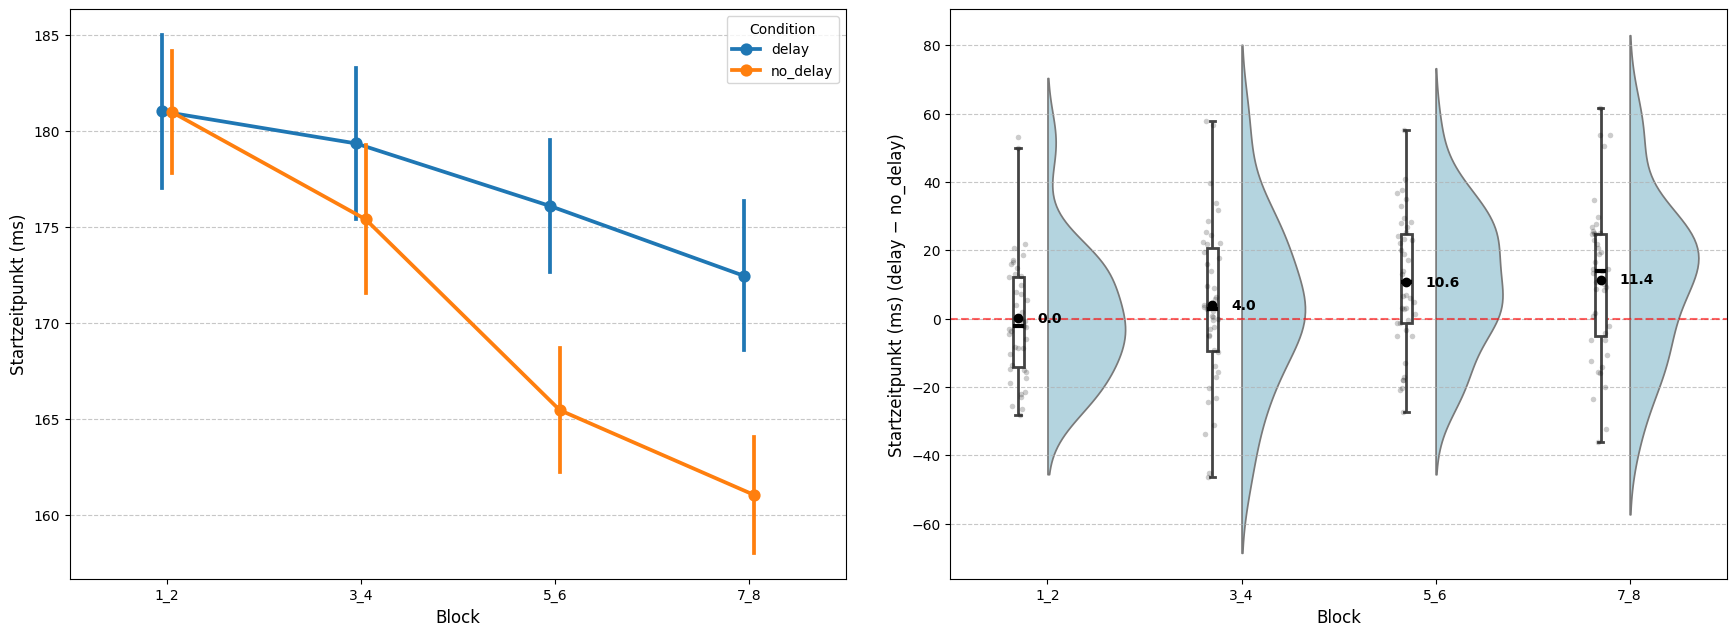

In [121]:
fig, ax = plot_results(
    stat_df=stat_df, 
    diff_df=df_diff_ballistic_start, 
    y_col="time_to_ballistic_start", 
    ylabel_left="Startzeitpunkt (ms)", 
    ylabel_right="Startzeitpunkt (ms) (delay − no_delay)",
    pair_order=None,
    base_size=12,
    decimals=1
)

In [122]:
df_diff_verification_duration = stat_df.pivot_table(
    index=['id', 'pair'], 
    columns='condition', 
    values='verification_duration'
).reset_index()
df_diff_verification_duration['diff'] = df_diff_verification_duration['delay'] - df_diff_verification_duration['no_delay']

In [123]:
df_results_verification_duration = run_posthoc_analysis(df_diff_verification_duration, "verification_duration")


Post-hoc Ergebnisse für verification_duration:
Block  M_No_Delay  SD_No_Delay  M_Delay  SD_Delay   Diff     t  p_adj     d
  1_2     110.474       30.824  114.595    34.618  4.122 1.877  0.067 0.286
  3_4     101.080       35.194  106.709    35.264  5.629 2.814  0.014 0.429
  5_6      94.078       35.577  100.290    38.329  6.212 2.674  0.014 0.408
  7_8      90.707       41.657  100.871    43.189 10.164 3.983  0.001 0.607


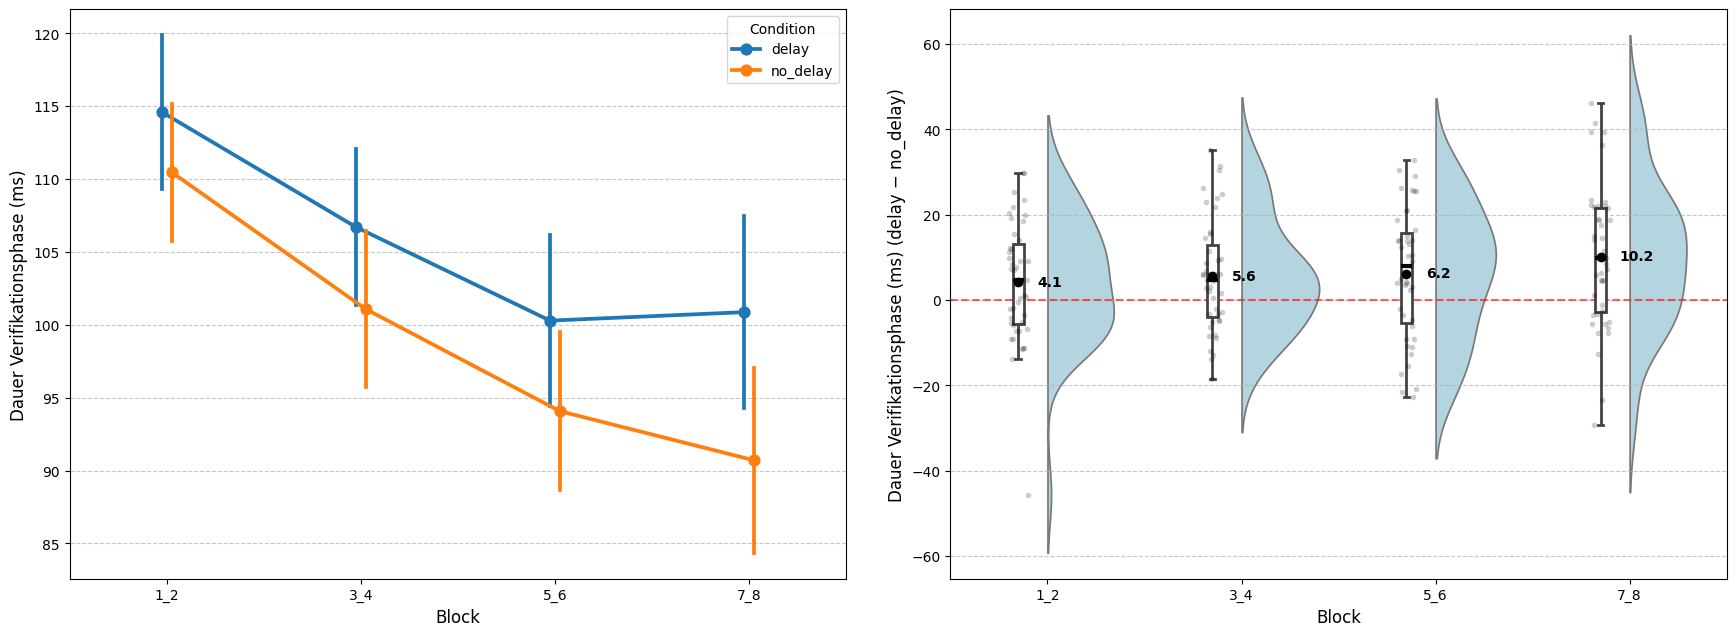

In [124]:
fig, ax = plot_results(
    stat_df=stat_df, 
    diff_df=df_diff_verification_duration, 
    y_col="verification_duration", 
    ylabel_left="Dauer Verifikationsphase (ms)", 
    ylabel_right="Dauer Verifikationsphase (ms) (delay − no_delay)",
    pair_order=None,
    base_size=12,
    decimals=1
)

In [125]:
aov = pg.rm_anova(
    dv="verification_duration",
    within=["condition", "pair"],
    subject="id",
    data=stat_df,
    detailed=True
)

print(aov)

             Source            SS  ddof1  ddof2           MS          F  \
0         condition   3668.723112      1     42  3668.723112  15.488151   
1              pair  15122.304879      3    126  5040.768293   9.096088   
2  condition * pair    428.200813      3    126   142.733604   2.050572   

      p_unc  p_GG_corr       ng2       eps  
0  0.000306   0.000306  0.007903  1.000000  
1  0.000017   0.000337  0.031790  0.638090  
2  0.110164   0.113925  0.000929  0.945895  


In [126]:
mean_by_block_delay = stat_df.groupby(["pair", "condition"])["verification_duration"].mean().reset_index()

print(mean_by_block_delay)

  pair condition  verification_duration
0  1_2     delay             114.595287
1  1_2  no_delay             110.473652
2  3_4     delay             106.709228
3  3_4  no_delay             101.080390
4  5_6     delay             100.289831
5  5_6  no_delay              94.078136
6  7_8     delay             100.871046
7  7_8  no_delay              90.707495


In [127]:
df_diff_undershoots = stat_df.pivot_table(
    index=['id', 'pair'], 
    columns='condition', 
    values='undershoots'
).reset_index()
df_diff_undershoots['diff'] = df_diff_undershoots['delay'] - df_diff_undershoots['no_delay']

In [128]:
df_diff_overshoots = stat_df.pivot_table(
    index=['id', 'pair'], 
    columns='condition', 
    values='overshoots'
).reset_index()
df_diff_overshoots['diff'] = df_diff_overshoots['delay'] - df_diff_overshoots['no_delay']

In [129]:
df_diff_auc = stat_df.pivot_table(
    index=['id', 'pair'], 
    columns='condition', 
    values='auc'
).reset_index()
df_diff_auc['diff'] = df_diff_auc['delay'] - df_diff_auc['no_delay']

In [130]:
df_diff_ballistic_duration = stat_df.pivot_table(
    index=['id', 'pair'], 
    columns='condition', 
    values='ballistic_duration'
).reset_index()
df_diff_ballistic_duration['diff'] = df_diff_ballistic_duration['delay'] - df_diff_ballistic_duration['no_delay']

In [131]:
df_diff_correction_duration = stat_df.pivot_table(
    index=['id', 'pair'], 
    columns='condition', 
    values='correction_duration'
).reset_index()
df_diff_correction_duration['diff'] = df_diff_correction_duration['delay'] - df_diff_correction_duration['no_delay']

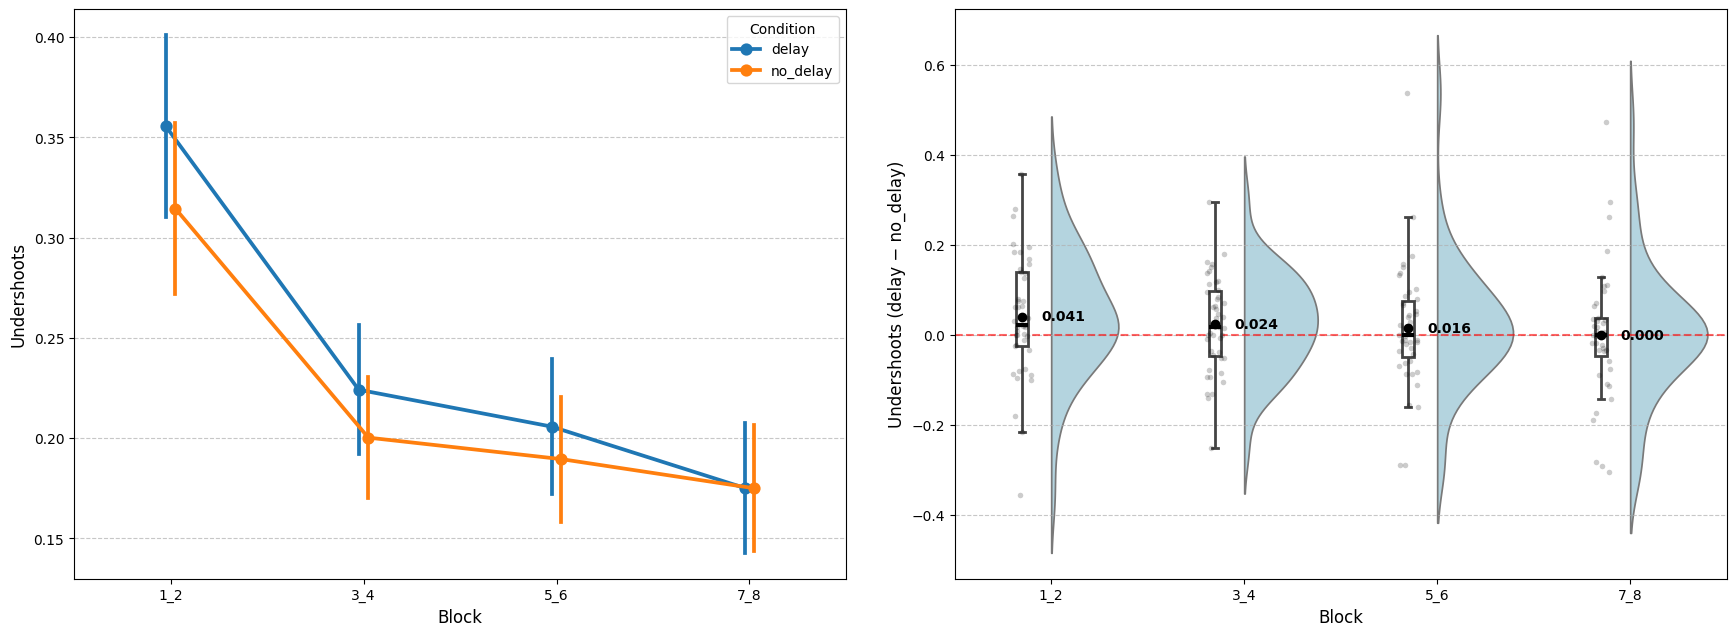

In [132]:
fig, ax = plot_results(
    stat_df=stat_df, 
    diff_df=df_diff_undershoots, 
    y_col="undershoots", 
    ylabel_left="Undershoots", 
    ylabel_right="Undershoots (delay − no_delay)",
    pair_order=None,
    base_size=12,
    decimals=3
)

In [133]:
aov = pg.rm_anova(
    dv="undershoots",
    within=["condition", "pair"],
    subject="id",
    data=stat_df,
    detailed=True
)

print(aov)

             Source        SS  ddof1  ddof2        MS          F  \
0         condition  0.035603      1     42  0.035603   2.161350   
1              pair  1.326427      3    126  0.442142  23.650532   
2  condition * pair  0.018671      3    126  0.006224   1.037480   

          p_unc     p_GG_corr       ng2       eps  
0  1.489725e-01  1.489725e-01  0.001971  1.000000  
1  3.293060e-12  1.460999e-09  0.068546  0.735223  
2  3.784414e-01  3.752045e-01  0.001035  0.928355  


In [134]:
df_results_undershoots = run_posthoc_analysis(df_diff_undershoots, "undershoots")


Post-hoc Ergebnisse für undershoots:
Block  M_No_Delay  SD_No_Delay  M_Delay  SD_Delay  Diff     t  p_adj     d
  1_2       0.315        0.281    0.356     0.297 0.041 1.992  0.212 0.304
  3_4       0.200        0.198    0.224     0.211 0.024 1.475  0.295 0.225
  5_6       0.190        0.204    0.206     0.221 0.016 0.779  0.587 0.119
  7_8       0.175        0.206    0.175     0.212 0.000 0.007  0.994 0.001


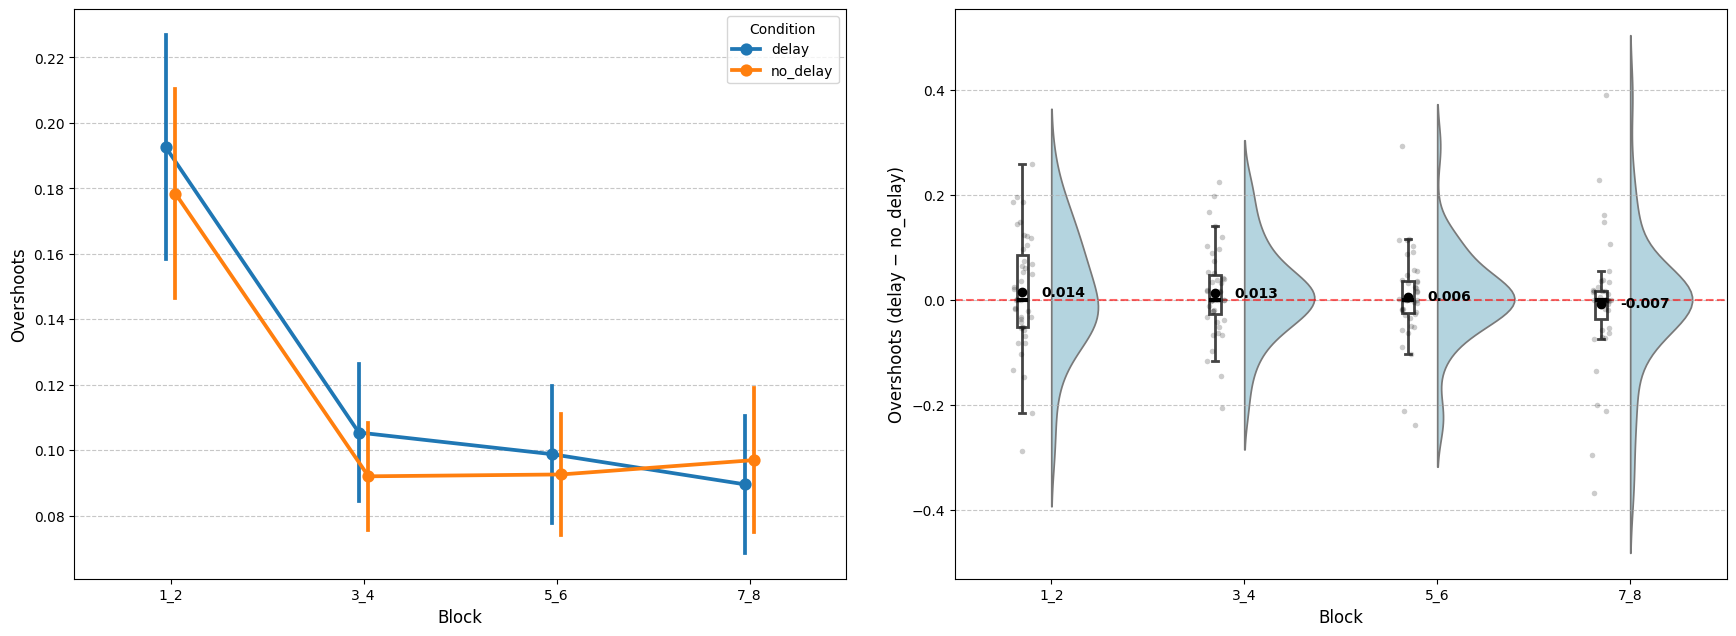

In [135]:
fig, ax = plot_results(
    stat_df=stat_df, 
    diff_df=df_diff_overshoots, 
    y_col="overshoots", 
    ylabel_left="Overshoots", 
    ylabel_right="Overshoots (delay − no_delay)",
    pair_order=None,
    base_size=12,
    decimals=3
)

In [136]:
aov = pg.rm_anova(
    dv="overshoots",
    within=["condition", "pair"],
    subject="id",
    data=stat_df,
    detailed=True
)

print(aov)

             Source        SS  ddof1  ddof2        MS          F  \
0         condition  0.003722      1     42  0.003722   0.385812   
1              pair  0.518543      3    126  0.172848  13.582103   
2  condition * pair  0.006433      3    126  0.002144   0.587139   

          p_unc  p_GG_corr       ng2       eps  
0  5.378659e-01   0.537866  0.000448  1.000000  
1  9.832264e-08   0.000002  0.058740  0.761387  
2  6.245282e-01   0.595991  0.000774  0.840804  


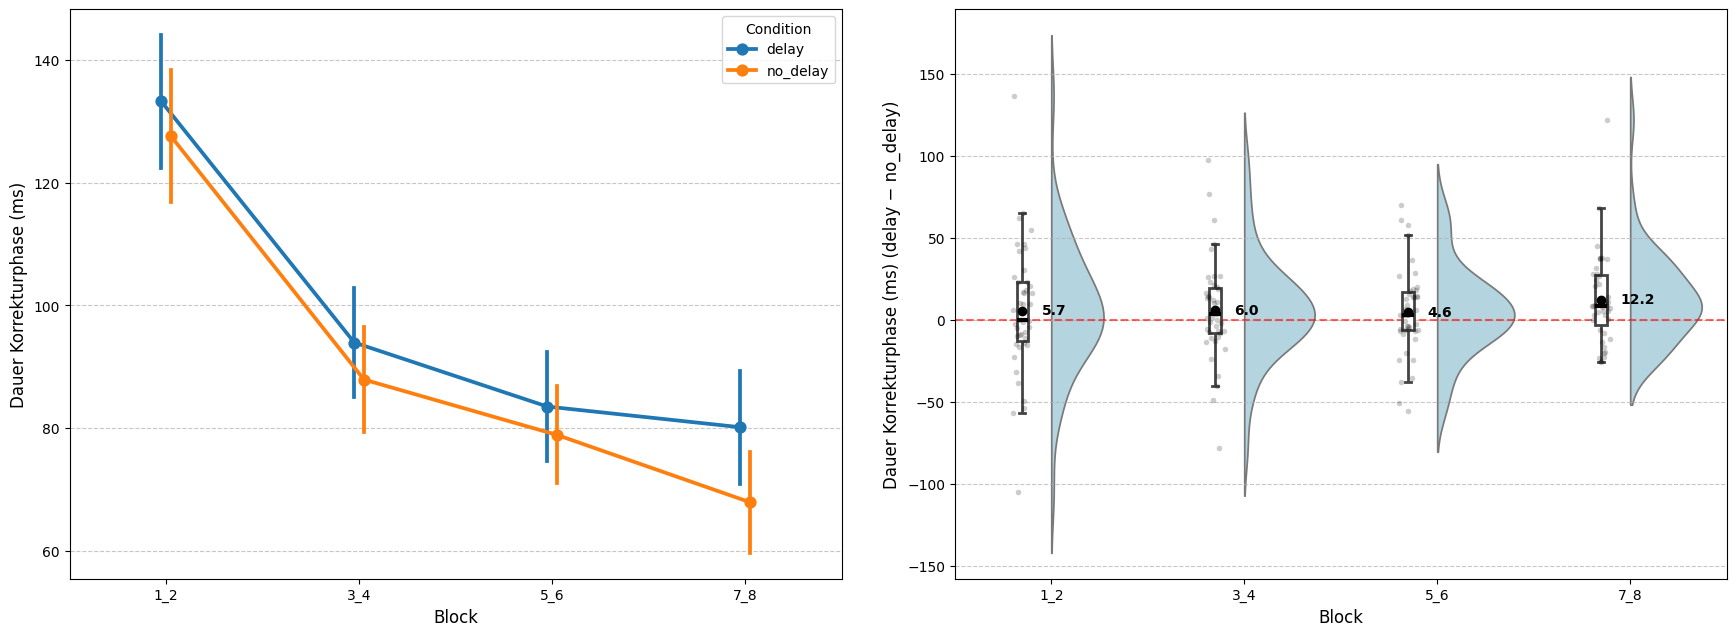

In [137]:
fig, ax = plot_results(
    stat_df=stat_df, 
    diff_df=df_diff_correction_duration, 
    y_col="correction_duration", 
    ylabel_left="Dauer Korrekturphase (ms)", 
    ylabel_right="Dauer Korrekturphase (ms) (delay − no_delay)",
    pair_order=None,
    base_size=12,
    decimals=1
)

In [138]:
aov = pg.rm_anova(
    dv="correction_duration",
    within=["condition", "pair"],
    subject="id",
    data=stat_df,
    detailed=True
)

print(aov)

             Source             SS  ddof1  ddof2            MS          F  \
0         condition    4375.844439      1     42   4375.844439   3.861778   
1              pair  163074.377046      3    126  54358.125682  44.225168   
2  condition * pair     763.651463      3    126    254.550488   0.902032   

          p_unc     p_GG_corr       ng2       eps  
0  5.603463e-02  5.603463e-02  0.003563  1.000000  
1  1.357258e-19  1.113506e-16  0.117592  0.830811  
2  4.422676e-01  4.323441e-01  0.000624  0.881238  


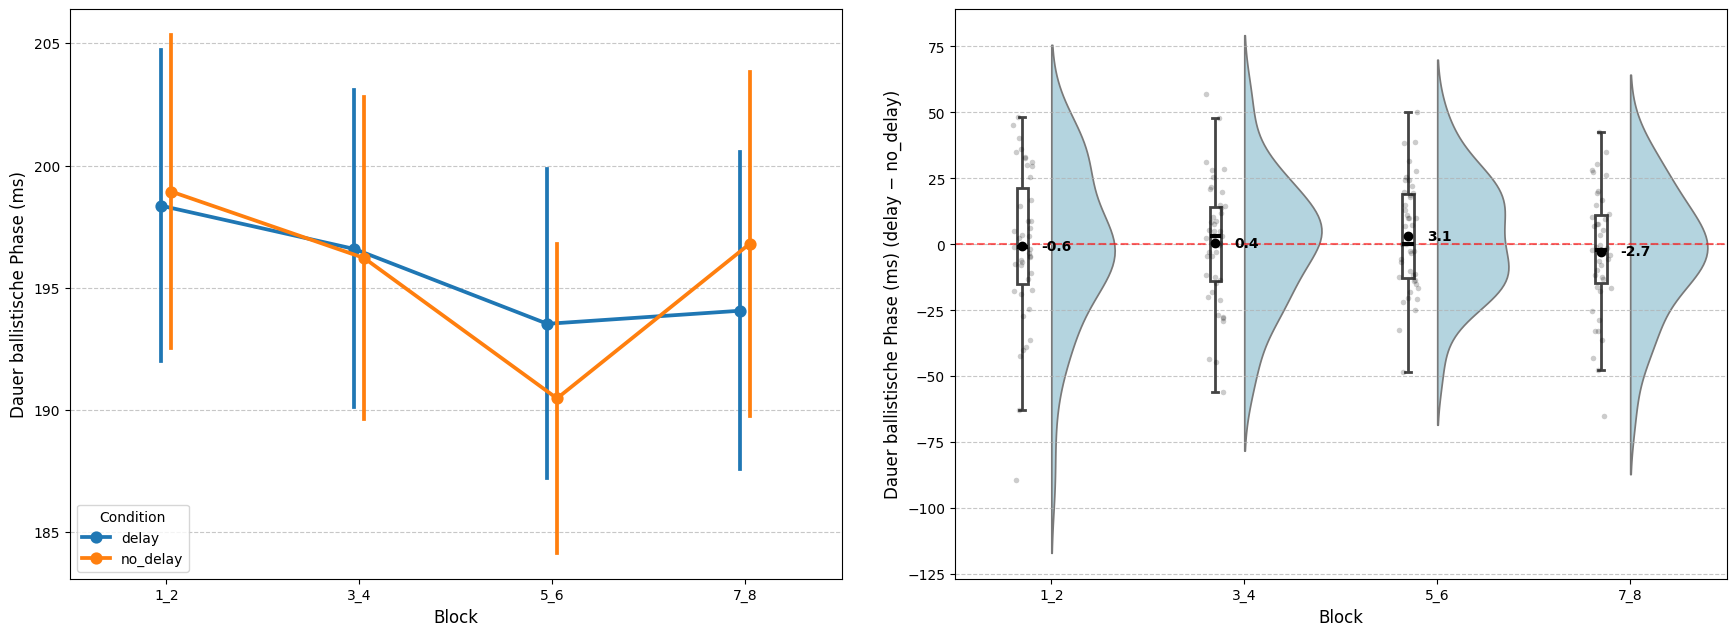

In [139]:
fig, ax = plot_results(
    stat_df=stat_df, 
    diff_df=df_diff_ballistic_duration, 
    y_col="ballistic_duration", 
    ylabel_left="Dauer ballistische Phase (ms)", 
    ylabel_right="Dauer ballistische Phase (ms) (delay − no_delay)",
    pair_order=None,
    base_size=12,
    decimals=1
)

In [140]:
aov = pg.rm_anova(
    dv="ballistic_duration",
    within=["condition", "pair"],
    subject="id",
    data=stat_df,
    detailed=True
)

print(aov)

             Source           SS  ddof1  ddof2          MS         F  \
0         condition     0.044711      1     42    0.044711  0.000055   
1              pair  1970.333734      3    126  656.777911  1.387166   
2  condition * pair   372.447997      3    126  124.149332  0.973795   

      p_unc  p_GG_corr           ng2       eps  
0  0.994113   0.994113  7.317035e-08  1.000000  
1  0.249787   0.253248  3.214147e-03  0.842156  
2  0.407392   0.399451  6.091511e-04  0.875857  


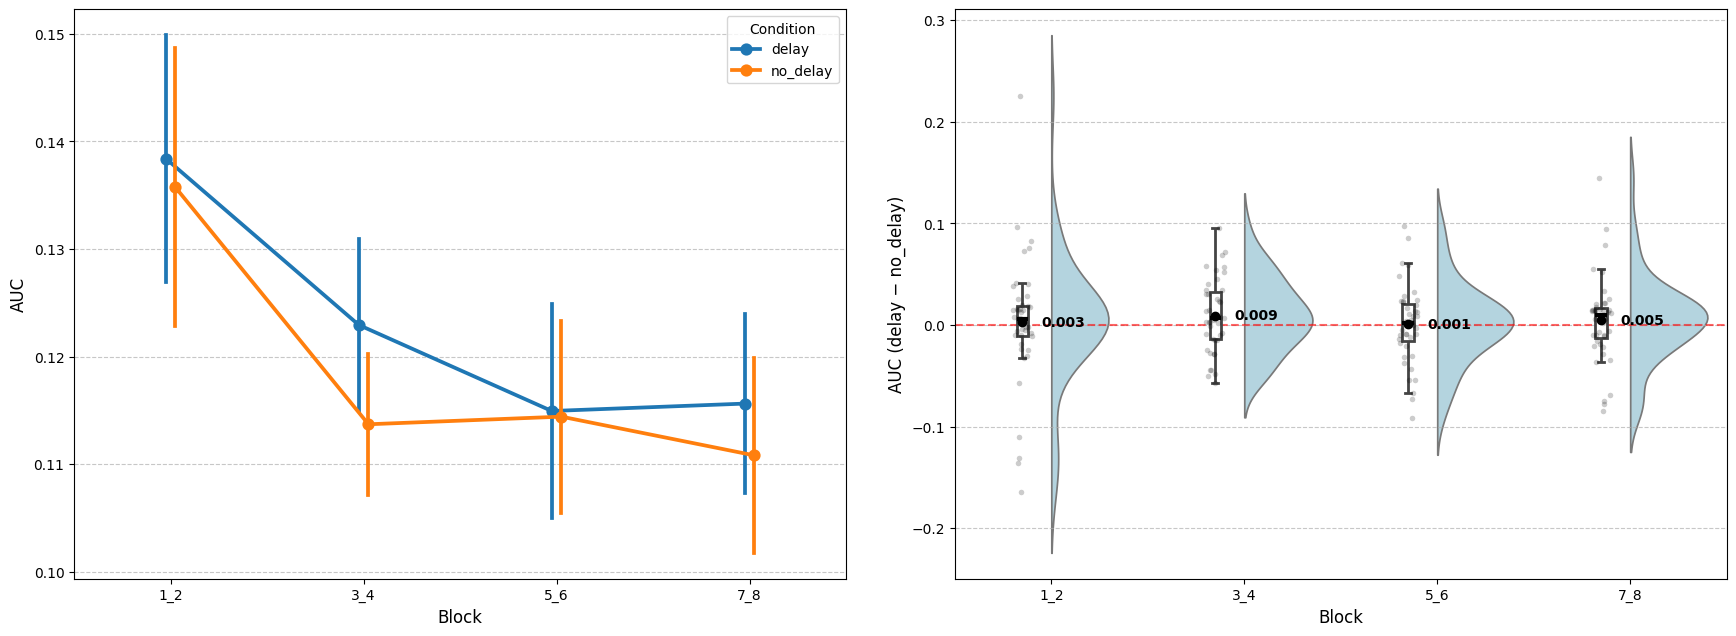

In [141]:
fig, ax = plot_results(
    stat_df=stat_df, 
    diff_df=df_diff_auc, 
    y_col="auc", 
    ylabel_left="AUC", 
    ylabel_right="AUC (delay − no_delay)",
    pair_order=None,
    base_size=12,
    decimals=3
)

In [142]:
aov = pg.rm_anova(
    dv="auc",
    within=["condition", "pair"],
    subject="id",
    data=stat_df,
    detailed=True
)

print(aov)

             Source        SS  ddof1  ddof2        MS         F     p_unc  \
0         condition  0.001599      1     42  0.001599  0.980898  0.327649   
1              pair  0.031428      3    126  0.010476  7.636320  0.000099   
2  condition * pair  0.000891      3    126  0.000297  0.334896  0.800124   

   p_GG_corr       ng2       eps  
0   0.327649  0.001202  1.000000  
1   0.000424  0.023113  0.779338  
2   0.735575  0.000671  0.729781  
